# EEIR Models Evaluation (Hugging Face)

This notebook loads the `disham993/ElectricalElectronicsIR` TEST dataset, and pulls your chosen finetuned/adapter models **directly from the Hugging Face Hub** to benchmark their retrieval performance!


In [ ]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth  # Do this in local & cloud setups
else:
    import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2
!pip install -q "sentence-transformers>=5.0,<5.4"
!pip install --upgrade "typing_extensions>=4.12"
!pip install -q llama-cpp-python \
    --extra-index-url https://abetlen.github.io/llama-cpp-python/whl/cu124
!pip install matplotlib seaborn

In [ ]:
from unsloth import FastSentenceTransformer
import os
import gc
import torch
import pandas as pd
from datasets import load_dataset, Dataset
from sentence_transformers.evaluation import InformationRetrievalEvaluator
from sentence_transformers import util
from huggingface_hub import hf_hub_download, HfApi
from llama_cpp import Llama
import ctypes
import llama_cpp

In [ ]:
# Data Prep: ONLY load the test dataset for a pure evaluation
print("Loading test dataset...")
stream_test = list(load_dataset("disham993/ElectricalElectronicsIR", split="test", streaming=True))
test_dataset = Dataset.from_generator(lambda: (yield from stream_test))

queries = dict(enumerate(test_dataset["question"]))
corpus = dict(enumerate(test_dataset["passage_text"]))
relevant_docs = {idx: [idx] for idx in queries}

evaluator = InformationRetrievalEvaluator(
    queries=queries,
    corpus=corpus,
    relevant_docs=relevant_docs,
    show_progress_bar=False,
    batch_size=128,
    score_functions={'cosine': util.cos_sim} 
)

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
/tmp/ipykernel_28999/3776330573.py:7: UserWarning: WARNING: Unsloth should be imported before [transformers, peft] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from unsloth import FastSentenceTransformer


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Loading test dataset...


In [ ]:
# Define a list of Hugging Face remote repos to pull directly for evaluation
huggingface_models_to_evaluate = [
    "google/embeddinggemma-300m",
    "unsloth/embeddinggemma-300m",
    "disham993/electrical-embeddinggemma-ir_lora",
    "disham993/electrical-embeddinggemma-ir_finetune_16bit",
    "disham993/electrical-embeddinggemma-ir_f16",
    "disham993/electrical-embeddinggemma-ir_q8_0",
    "disham993/electrical-embeddinggemma-ir_q5_k_m",
    "disham993/electrical-embeddinggemma-ir_q4_k_m"
]

valid_model_paths = huggingface_models_to_evaluate
print(f"Models queued for evaluation from Hugging Face:\n")
for vp in valid_model_paths:
    print("-", vp)

Models queued for evaluation from Hugging Face:

- google/embeddinggemma-300m
- unsloth/embeddinggemma-300m
- disham993/electrical-embeddinggemma-ir_lora
- disham993/electrical-embeddinggemma-ir_finetune_16bit
- disham993/electrical-embeddinggemma-ir_f16
- disham993/electrical-embeddinggemma-ir_q8_0
- disham993/electrical-embeddinggemma-ir_q5_k_m
- disham993/electrical-embeddinggemma-ir_q4_k_m


In [ ]:
# 1. Define a callback handler that does nothing and register it as a C-level callback
@llama_cpp.llama_log_callback
def _empty_log_callback(level, text, user_data):
    pass

# 2. Tell llama_cpp to route all internal C logging to our empty python function
llama_cpp.llama_log_set(_empty_log_callback, ctypes.c_void_p())

class DummyModelCardData:
    def set_evaluation_metrics(self, *args, **kwargs):
        pass

class GGUFEmbeddingWrapper:
    def __init__(self, repo_id):
        self.repo_id = repo_id
        api = HfApi()
        files = api.list_repo_files(repo_id)
        gguf_file = next((f for f in files if f.endswith('.gguf')), None)
        if not gguf_file:
            raise ValueError(f"No .gguf file found in {repo_id}")
            
        print(f"Downloading/Using {gguf_file} from {repo_id}...")
        model_path = hf_hub_download(repo_id=repo_id, filename=gguf_file)
        
        self.llm = Llama(
            model_path=model_path,
            embedding=True,
            n_gpu_layers=-1, 
            n_ctx=2048,
            verbose=False
        )
        self.dtype = torch.float16
        self.model_card_data = DummyModelCardData()
        
    def encode(self, sentences, batch_size=None, **kwargs):
        # Pop convert_to_tensor safely
        convert_to_tensor = kwargs.pop('convert_to_tensor', True)
        
        if isinstance(sentences, str):
            sentences = [sentences]
            
        # Handling list of dicts for corpus
        if isinstance(sentences, list) and len(sentences) > 0 and isinstance(sentences[0], dict):
            sentences = [(doc.get("title", "") + " " + doc.get("text", "")).strip() for doc in sentences]
            
        embeddings = []
        for text in sentences:
            res = self.llm.create_embedding(text)
            embeddings.append(res['data'][0]['embedding'])
            
        tensors = torch.tensor(embeddings, dtype=torch.float32)
        if convert_to_tensor:
            if torch.cuda.is_available():
                tensors = tensors.cuda()
            return tensors
        return tensors.cpu().numpy()

    def __getattr__(self, name):
        if name.startswith("encode_"):
            def wrapper(*args, **kwargs):
                kwargs['convert_to_tensor'] = True
                return self.encode(*args, **kwargs)
            return wrapper
        raise AttributeError(f"'{self.__class__.__name__}' object has no attribute '{name}'")

In [4]:
from sentence_transformers import SentenceTransformer
import warnings
warnings.filterwarnings('ignore')

results = []
metrics_to_plot = ['Cosine Map@100', 'Cosine Ndcg@10', 'Cosine Mrr@10', 'Cosine Recall@10']

for model_path in valid_model_paths:
    print(f"\n{'='*50}")
    
    # Check if this is a GGUF model
    is_gguf = '_q' in model_path or '_f16' in model_path
    
    if is_gguf:
        print(f"🦙 [LlamaCPP Engine] Loading '{model_path}'...")
        try:
            model = GGUFEmbeddingWrapper(model_path)
            # Evaluator
            metrics = evaluator(model)
            row = {"Model Info": model_path + " (LlamaCPP/GGUF)"}
            for k in metrics_to_plot: row[k] = metrics.get(k.lower().replace(' ', '_'), 0)
            results.append(row)
            print(f"✅ Success! MAP@100: {row.get('Cosine Map@100', row.get('cosine_map@100', 0)):.4f}")
        except Exception as e:
            print(f"❌ Failed: {e}")
            
        if 'model' in locals():
            import gc; del model; gc.collect(); torch.cuda.empty_cache()
            
    else:
        # standard 16bit / lora / base evaluation using Unsloth
        print(f"🦥 [Unsloth Engine] Pulling '{model_path}' from HF...")
        try:
            model = FastSentenceTransformer.from_pretrained(model_path, max_seq_length=2048)
            with torch.autocast(device_type="cuda", dtype=model.dtype, enabled=model.dtype!=torch.float16):
                metrics = evaluator(model)
            row = {"Model Info": model_path + " (Unsloth)"}
            for k in metrics_to_plot: row[k] = metrics.get(k.lower().replace(' ', '_'), 0)
            results.append(row)
            print(f"✅ Success! MAP@100: {row.get('Cosine Map@100', row.get('cosine_map@100', 0)):.4f}")
        except Exception as e:
            print(f"❌ Failed: {e}")
            
        if 'model' in locals():
            import gc; del model; gc.collect(); torch.cuda.empty_cache()



🦥 [Unsloth Engine] Pulling 'google/embeddinggemma-300m' from HF...
==((====))==  Unsloth 2026.4.6: Fast Gemma3 patching. Transformers: 4.56.2.
   \\   /|    NVIDIA GeForce RTX 3090. Num GPUs = 1. Max memory: 23.559 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.6. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
✅ Success! MAP@100: 0.5753

🦥 [Unsloth Engine] Pulling 'unsloth/embeddinggemma-300m' from HF...
==((====))==  Unsloth 2026.4.6: Fast Gemma3 patching. Transformers: 4.56.2.
   \\   /|    NVIDIA GeForce RTX 3090. Num GPUs = 1. Max memory: 23.559 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.6. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslotha

modules.json:   0%|          | 0.00/573 [00:00<?, ?B/s]

==((====))==  Unsloth 2026.4.6: Fast Gemma3 patching. Transformers: 4.56.2.
   \\   /|    NVIDIA GeForce RTX 3090. Num GPUs = 1. Max memory: 23.559 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.6. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


adapter_model.safetensors:   0%|          | 0.00/16.8M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

✅ Success! MAP@100: 0.9844

🦙 [LlamaCPP Engine] Loading 'disham993/electrical-embeddinggemma-ir_q5_k_m'...
Downloading/Using embeddinggemma-300m.Q5_K_M.gguf from disham993/electrical-embeddinggemma-ir_q5_k_m...


embeddinggemma-300m.Q5_K_M.gguf:   0%|          | 0.00/247M [00:00<?, ?B/s]

✅ Success! MAP@100: 0.9824

🦙 [LlamaCPP Engine] Loading 'disham993/electrical-embeddinggemma-ir_q4_k_m'...
Downloading/Using embeddinggemma-300m.Q4_K_M.gguf from disham993/electrical-embeddinggemma-ir_q4_k_m...


embeddinggemma-300m.Q4_K_M.gguf:   0%|          | 0.00/236M [00:00<?, ?B/s]

✅ Success! MAP@100: 0.9841


In [5]:
# Display a nicely formatted DataFrame chart of performance comparisons
df = pd.DataFrame(results)
if not df.empty:
    is_base = df["Model Info"].str.contains("google/embeddinggemma-300m") | df["Model Info"].str.contains("unsloth/embeddinggemma-300m")
    
    df_base = df[is_base].copy()
    df_finetuned = df[~is_base].copy()
    
    df_base = df_base.sort_values(by="Cosine Map@100", ascending=False)
    df_finetuned = df_finetuned.sort_values(by="Cosine Map@100", ascending=False)
    
    df = pd.concat([df_base, df_finetuned]).reset_index(drop=True)
    
    rename_mapping = {
        'cosine_accuracy@1': 'Cosine Accuracy@1',
        'cosine_accuracy@3': 'Cosine Accuracy@3',
        'cosine_accuracy@5': 'Cosine Accuracy@5',
        'cosine_accuracy@10': 'Cosine Accuracy@10',
        'cosine_precision@1': 'Cosine Precision@1',
        'cosine_precision@3': 'Cosine Precision@3',
        'cosine_precision@5': 'Cosine Precision@5',
        'cosine_precision@10': 'Cosine Precision@10',
        'cosine_recall@1': 'Cosine Recall@1',
        'cosine_recall@3': 'Cosine Recall@3',
        'cosine_recall@5': 'Cosine Recall@5',
        'cosine_recall@10': 'Cosine Recall@10',
        'cosine_ndcg@10': 'Cosine Ndcg@10',
        'cosine_mrr@10': 'Cosine Mrr@10',
        'cosine_map@100': 'Cosine Map@100'
    }
    df = df.rename(columns=rename_mapping)
    pd.set_option('display.max_columns', None)
    display(df)
else:
    print("No evaluation data gathered.")


,Model Info,Cosine Map@100,Cosine Ndcg@10,Cosine Mrr@10,Cosine Recall@10
0,google/embeddinggemma-300m (Unsloth),0.575346,0.622131,0.568188,0.7925
1,unsloth/embeddinggemma-300m (Unsloth),0.575346,0.622131,0.568188,0.7925
2,disham993/electrical-embeddinggemma-ir_f16 (Ll...,0.984939,0.988665,0.984925,0.9995
3,disham993/electrical-embeddinggemma-ir_q8_0 (L...,0.984438,0.988296,0.984425,0.9995
4,disham993/electrical-embeddinggemma-ir_q4_k_m ...,0.984053,0.987870,0.984000,0.9990
5,disham993/electrical-embeddinggemma-ir_q5_k_m ...,0.982352,0.986597,0.982292,0.9990
6,disham993/electrical-embeddinggemma-ir_finetun...,0.979705,0.984874,0.979705,1.0000
7,disham993/electrical-embeddinggemma-ir_lora (U...,0.979455,0.984690,0.979455,1.0000


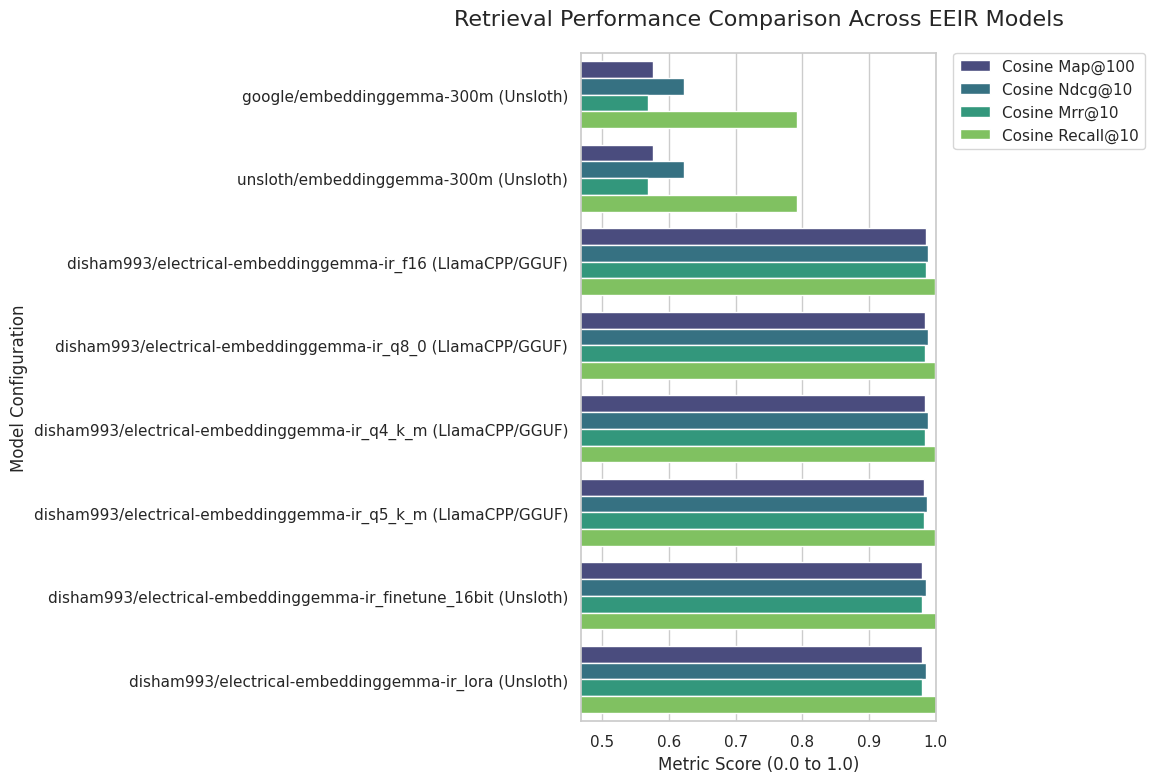

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

if not df.empty:
    # Set up styling
    sns.set_theme(style="whitegrid")
    
    # We will plot MAP@100 and NDCG@10 as they are prime ranking metrics
    metrics_to_plot = ['Cosine Map@100', 'Cosine Ndcg@10', 'Cosine Mrr@10', 'Cosine Recall@10']
    
    # Prepare data
    plot_df = df.melt(id_vars='Model Info', value_vars=metrics_to_plot, 
                      var_name='Metric', value_name='Score')
    
    # Create the figure
    plt.figure(figsize=(12, 8))
    
    # Create a grouped barplot
    ax = sns.barplot(
        data=plot_df, 
        y='Model Info', 
        x='Score', 
        hue='Metric',
        palette='viridis' # A nice scientific palette
    )
    
    plt.title('Retrieval Performance Comparison Across EEIR Models', fontsize=16, pad=20)
    plt.xlabel('Metric Score (0.0 to 1.0)', fontsize=12)
    plt.ylabel('Model Configuration', fontsize=12)
    
    # Set limits to zoom in on the relevant difference (assumes scores are mostly between 0.4 and 1.0)
    # Automatically adjust x limit to make differences more visible
    min_score = max(0, plot_df['Score'].min() - 0.1)
    plt.xlim(min_score, 1.0)
    
    # Move legend outside the plot
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    
    plt.tight_layout()
    plt.show()
else:
    print("DataFrame is empty, nothing to plot.")
